<a href="https://colab.research.google.com/github/mamajonovzokhidjon/neuro-cosmic-topology/blob/main/Neuro_Cosmic_Topology_Comparative_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mamajonovzokhidjon/neuro-cosmic-topology/blob/main/Neuro_Cosmic_Topology_Comparative_Analysis.ipynb)


 SYSTEM ANALYSIS: Cosmic Web Simulation (Barabási-Albert)
• Nodes (|V|): 300
• Edges (|E|): 891
• Average Degree (<k>): 5.9400
• Clustering Coefficient (C): 0.0653
• Average Shortest Path Length (L): 3.0860

 SYSTEM ANALYSIS: Human Neural Connectome (Watts-Strogatz)
• Nodes (|V|): 300
• Edges (|E|): 900
• Average Degree (<k>): 6.0000
• Clustering Coefficient (C): 0.5213
• Average Shortest Path Length (L): 5.6817



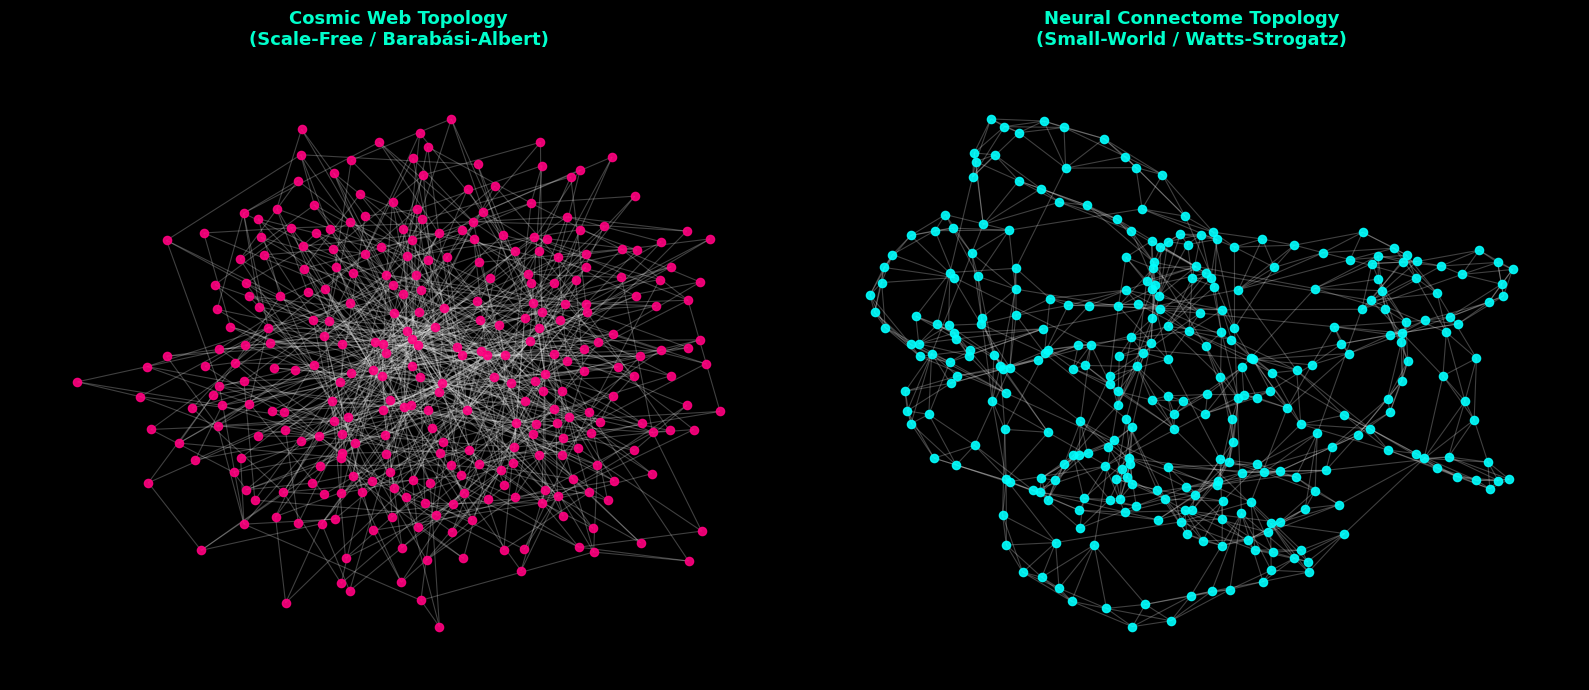

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# 1. PARAMETER DEFINITION
# Scale-free properties for Cosmic Web and Small-world properties for Neural Connectomes
N = 300       # Number of nodes
m_ba = 3      # Number of edges to attach from a new node to existing nodes (Barabási-Albert)
k_ws = 6      # Each node is connected to k nearest neighbors in ring topology (Watts-Strogatz)
p_ws = 0.05   # Probability of rewiring each edge (Watts-Strogatz)

# 2. NETWORK GENERATION
# Cosmic Web Simulation (Scale-Free Network Model)
G_cosmic = nx.barabasi_albert_graph(n=N, m=m_ba)

# Human Neural Connectome Simulation (Small-World Network Model)
G_neural = nx.watts_strogatz_graph(n=N, k=k_ws, p=p_ws)

# 3. TOPOLOGICAL METRICS COMPUTATION
def compute_and_print_metrics(graph, network_name):
    """
    Computes and prints fundamental topological metrics of a given network graph.
    """
    num_nodes = graph.number_of_nodes()
    num_edges = graph.number_of_edges()
    avg_degree = sum(dict(graph.degree()).values()) / num_nodes
    clustering_coeff = nx.average_clustering(graph)

    # Handle potentially disconnected graphs safely for path length calculation
    try:
        avg_path_length = nx.average_shortest_path_length(graph)
    except nx.NetworkXUnconnectedGraph:
        largest_cc = max(nx.connected_components(graph), key=len)
        subgraph = graph.subgraph(largest_cc)
        avg_path_length = nx.average_shortest_path_length(subgraph)

    print(f"==========================================")
    print(f" SYSTEM ANALYSIS: {network_name}")
    print(f"==========================================")
    print(f"• Nodes (|V|): {num_nodes}")
    print(f"• Edges (|E|): {num_edges}")
    print(f"• Average Degree (<k>): {avg_degree:.4f}")
    print(f"• Clustering Coefficient (C): {clustering_coeff:.4f}")
    print(f"• Average Shortest Path Length (L): {avg_path_length:.4f}\n")

    return clustering_coeff, avg_path_length

# Execute metrics computation
metrics_cosmic = compute_and_print_metrics(G_cosmic, "Cosmic Web Simulation (Barabási-Albert)")
metrics_neural = compute_and_print_metrics(G_neural, "Human Neural Connectome (Watts-Strogatz)")

# 4. PUBLICATION-READY VISUALIZATION (Dark Themed Dual-Panel Plot)
plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Generate spring layouts for consistent spatial distribution
pos_cosmic = nx.spring_layout(G_cosmic, seed=42)
pos_neural = nx.spring_layout(G_neural, seed=42)

# Panel 1: Cosmic Web Topology
axes[0].set_title("Cosmic Web Topology\n(Scale-Free / Barabási-Albert)", fontsize=13, fontweight='bold', color='#00ffcc', pad=15)
nx.draw_networkx_nodes(G_cosmic, pos_cosmic, ax=axes[0], node_size=35, node_color='#ff007f', alpha=0.9)
nx.draw_networkx_edges(G_cosmic, pos_cosmic, ax=axes[0], alpha=0.25, edge_color='#ffffff', width=0.8)
axes[0].axis('off')

# Panel 2: Neural Connectome Topology
axes[1].set_title("Neural Connectome Topology\n(Small-World / Watts-Strogatz)", fontsize=13, fontweight='bold', color='#00ffcc', pad=15)
nx.draw_networkx_nodes(G_neural, pos_neural, ax=axes[1], node_size=35, node_color='#00ffff', alpha=0.9)
nx.draw_networkx_edges(G_neural, pos_neural, ax=axes[1], alpha=0.25, edge_color='#ffffff', width=0.8)
axes[1].axis('off')

# Final adjustments and export
plt.tight_layout()
plt.savefig('neuro_cosmic_topology_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


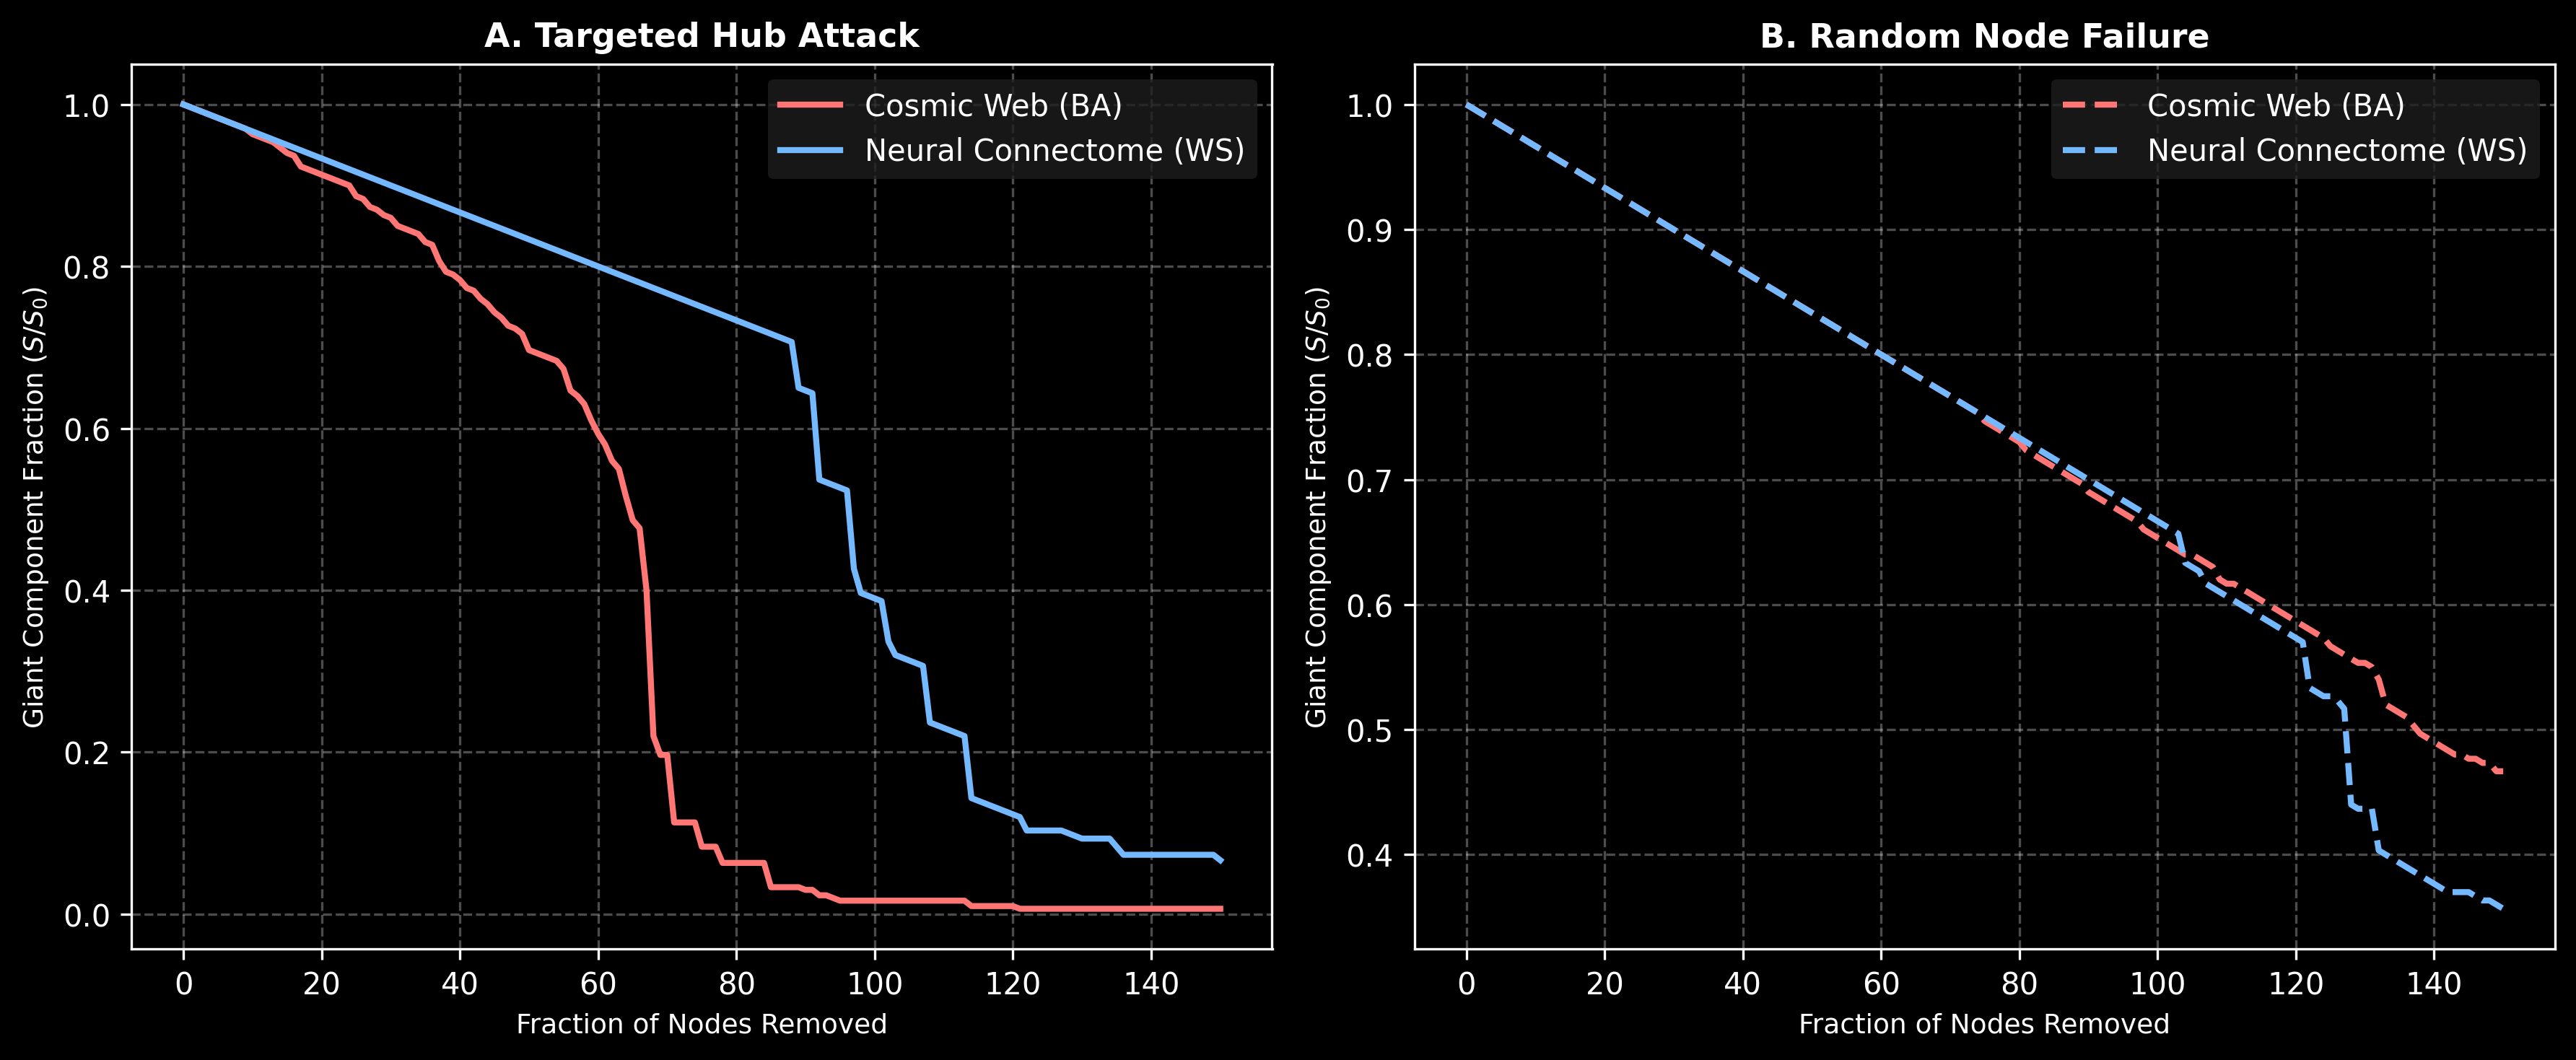

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from typing import List

# 1. Initialize benchmark topologies for cosmic web and neural connectome
cosmic_G = nx.barabasi_albert_graph(n=300, m=3)
neural_G = nx.watts_strogatz_graph(n=300, k=6, p=0.05)

# 2. Professional Network Robustness Analyzer Module
class NetworkRobustnessAnalyzer:
    """
    Evaluates and compares the structural resilience of complex networks
    under targeted hub removal and random node failure.
    """
    def __init__(self, graph: nx.Graph, network_name: str) -> None:
        self.graph = graph.copy()
        self.network_name = network_name
        self.original_size = len(graph)

    def calculate_largest_component_fraction(self, g: nx.Graph) -> float:
        """Computes the relative size of the giant connected component."""
        if len(g) == 0:
            return 0.0
        largest_cc = max(nx.connected_components(g), key=len)
        return len(largest_cc) / self.original_size

    def simulate_attack(self, strategy: str = "targeted") -> List[float]:
        """
        Simulates node removal via targeted attacks (highest degree first)
        or random failures.
        """
        g = self.graph.copy()
        resilience_curve = [self.calculate_largest_component_fraction(g)]
        num_steps = min(self.original_size - 1, int(self.original_size * 0.5))

        for _ in range(num_steps):
            if len(g) <= 1:
                break
            if strategy == "targeted":
                node_to_remove = max(g.degree, key=lambda x: x[1])[0]
            elif strategy == "random":
                node_to_remove = np.random.choice(list(g.nodes()))

            g.remove_node(node_to_remove)
            resilience_curve.append(self.calculate_largest_component_fraction(g))

        return resilience_curve

# 3. Publication-ready visualization function
def plot_comparative_resilience(cosmic_graph: nx.Graph, neural_graph: nx.Graph) -> None:
    """
    Generates a dual-panel comparative resilience plot contrasting
    Scale-Free and Small-World network topologies.
    """
    cosmic_analyzer = NetworkRobustnessAnalyzer(cosmic_graph, "Cosmic Web (BA)")
    neural_analyzer = NetworkRobustnessAnalyzer(neural_graph, "Neural Connectome (WS)")

    cosmic_targeted = cosmic_analyzer.simulate_attack(strategy="targeted")
    neural_targeted = neural_analyzer.simulate_attack(strategy="targeted")
    cosmic_random = cosmic_analyzer.simulate_attack(strategy="random")
    neural_random = neural_analyzer.simulate_attack(strategy="random")

    plt.style.use('dark_background')
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=300)

    # Panel A: Targeted Hub Attacks
    axes[0].plot(cosmic_targeted, label='Cosmic Web (BA)', color='#ff7675', linewidth=2)
    axes[0].plot(neural_targeted, label='Neural Connectome (WS)', color='#74b9ff', linewidth=2)
    axes[0].set_title('A. Targeted Hub Attack', fontsize=11, fontweight='bold')
    axes[0].set_xlabel('Fraction of Nodes Removed', fontsize=9)
    axes[0].set_ylabel('Giant Component Fraction ($S / S_0$)', fontsize=9)
    axes[0].grid(True, linestyle='--', alpha=0.3)
    axes[0].legend(facecolor='#1e1e1e', edgecolor='none')

    # Panel B: Random Failures
    axes[1].plot(cosmic_random, label='Cosmic Web (BA)', color='#ff7675', linestyle='--', linewidth=2)
    axes[1].plot(neural_random, label='Neural Connectome (WS)', color='#74b9ff', linestyle='--', linewidth=2)
    axes[1].set_title('B. Random Node Failure', fontsize=11, fontweight='bold')
    axes[1].set_xlabel('Fraction of Nodes Removed', fontsize=9)
    axes[1].set_ylabel('Giant Component Fraction ($S / S_0$)', fontsize=9)
    axes[1].grid(True, linestyle='--', alpha=0.3)
    axes[1].legend(facecolor='#1e1e1e', edgecolor='none')

    plt.tight_layout()
    plt.show()

# Execute analysis and render plots
plot_comparative_resilience(cosmic_G, neural_G)


             TOPOLOGICAL METRICS COMPARATIVE REPORT              
Clustering Coefficient    | Cosmic: 0.0664 | Neural: 0.5156
Average Path Length       | Cosmic: 3.0060 | Neural: 5.8129
Mean Degree               | Cosmic: 5.9400 | Neural: 6.0000
Max Degree                | Cosmic: 52.0000 | Neural: 8.0000


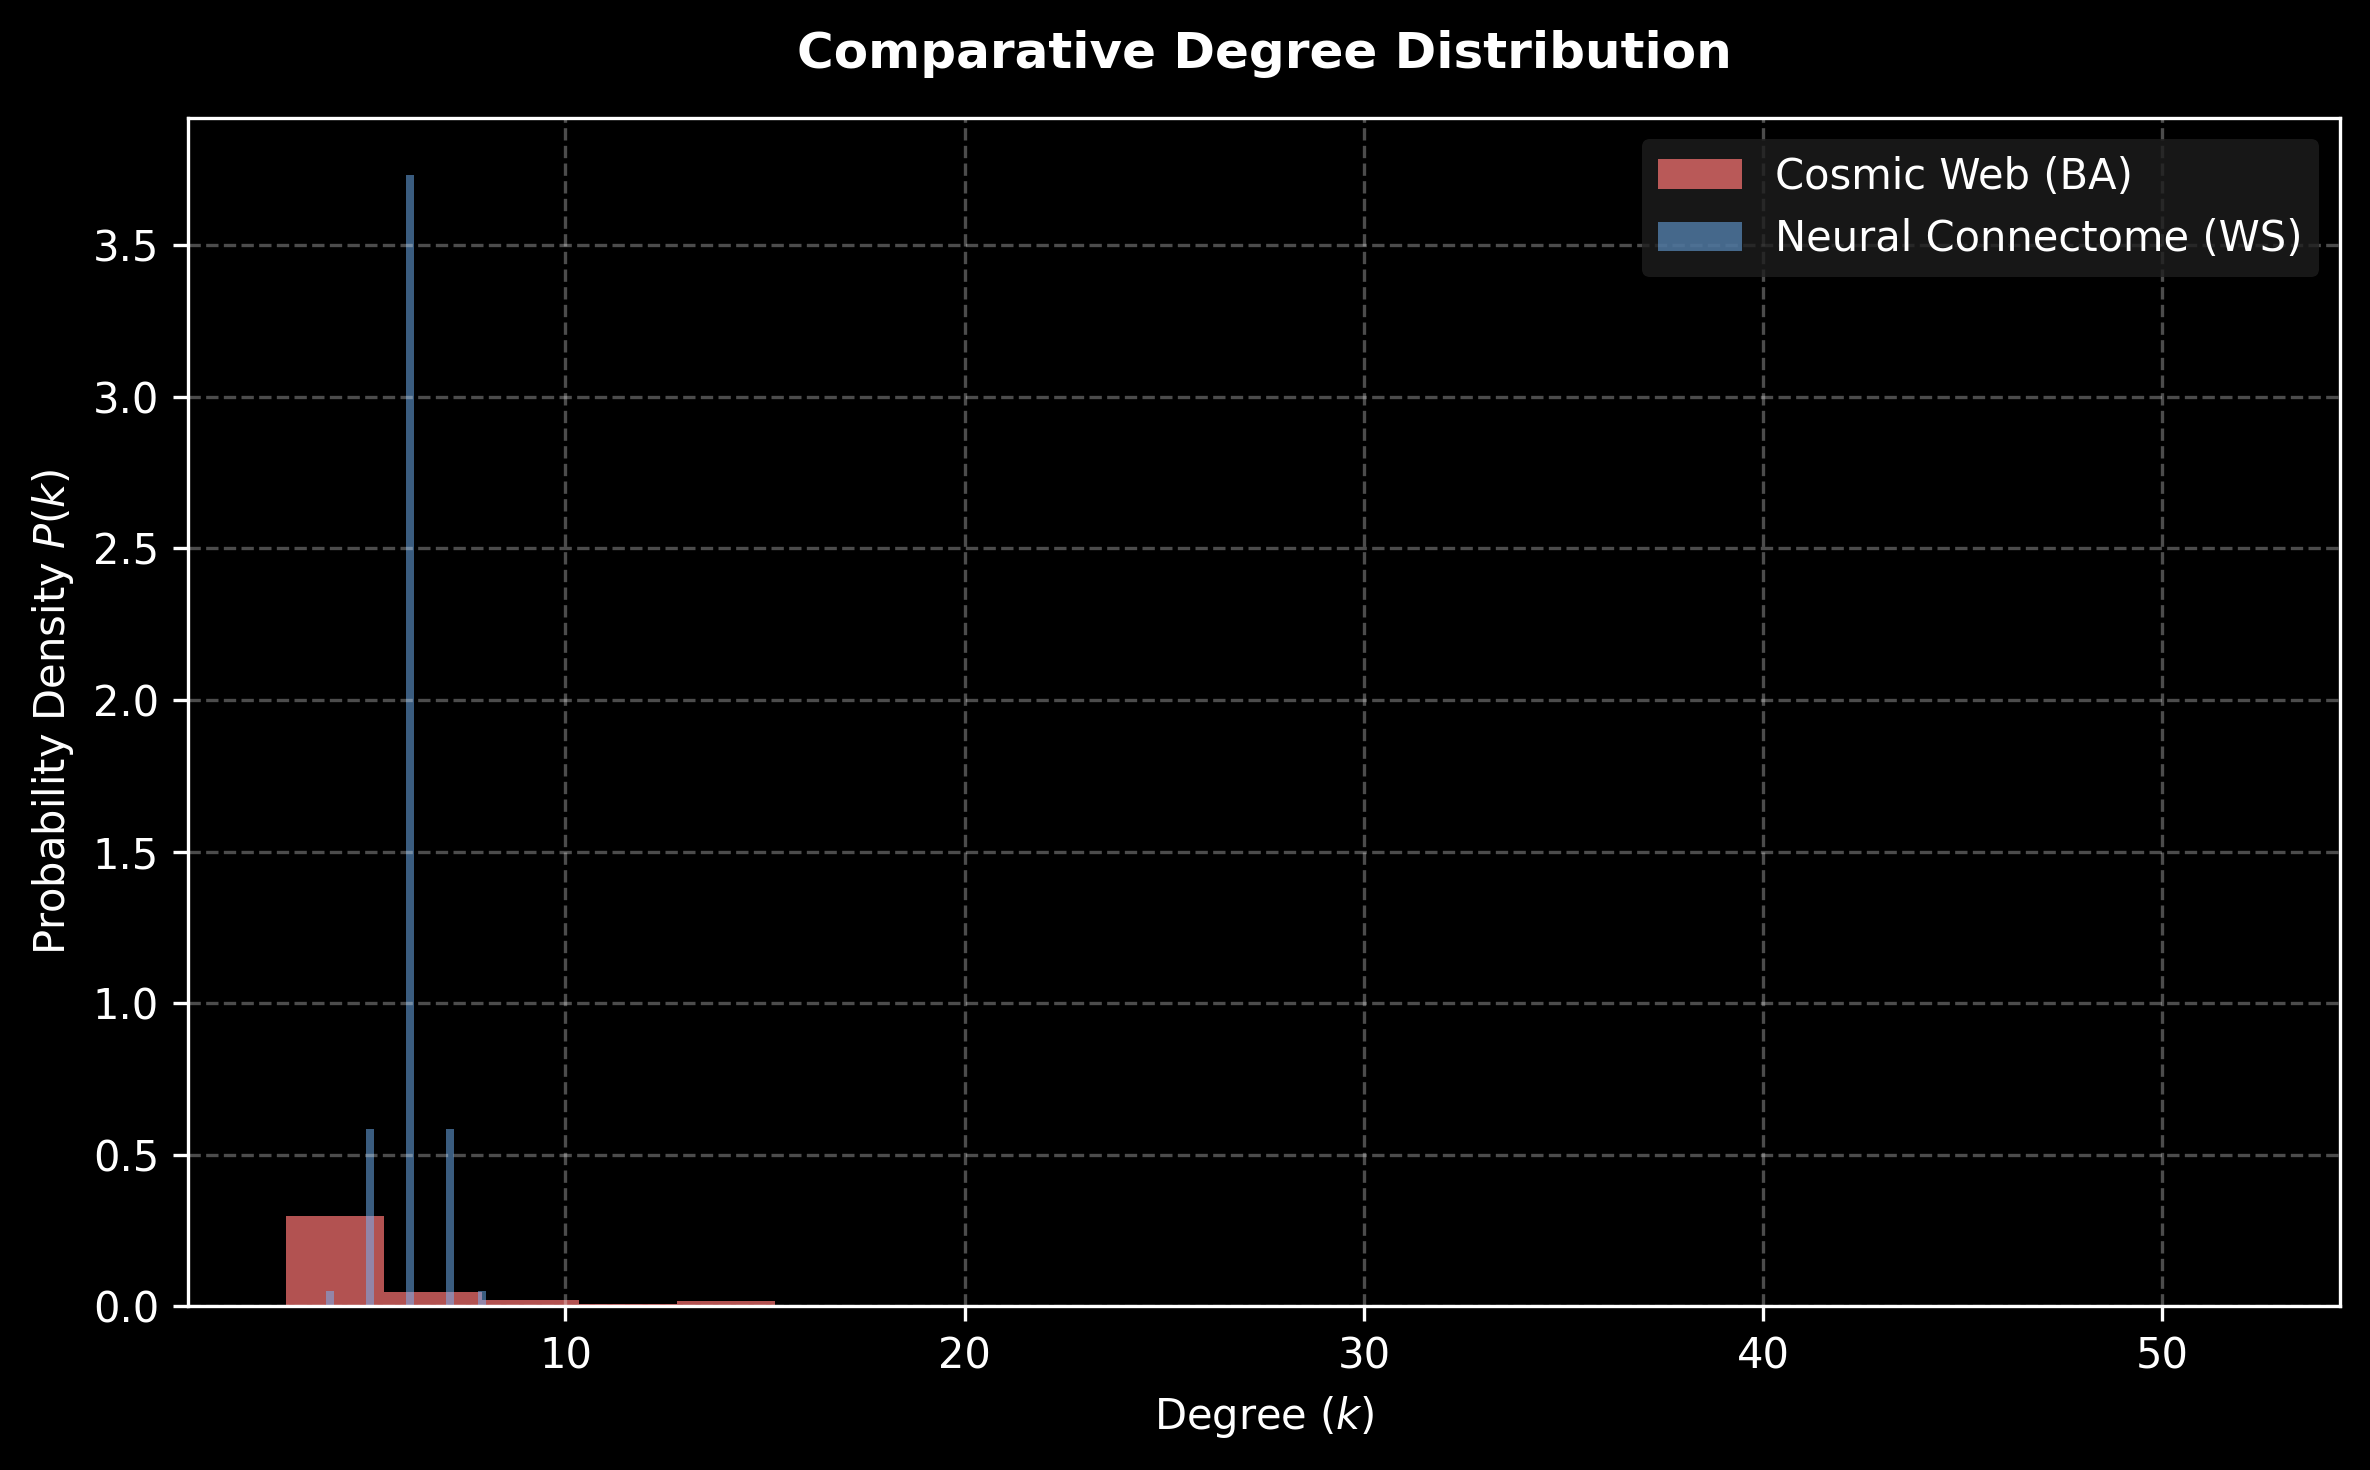

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from typing import Dict, List

# 1. Initialize comprehensive network structures for benchmarking
n_nodes = 300
cosmic_G = nx.barabasi_albert_graph(n=n_nodes, m=3)
neural_G = nx.watts_strogatz_graph(n=n_nodes, k=6, p=0.05)

# 2. Comprehensive Topological Metrics Analyzer Module
class TopologicalMetricsAnalyzer:
    """
    Computes core topological properties for comparative network analysis:
    - Average Clustering Coefficient
    - Characteristic Path Length (Giant Component)
    - Degree Distribution Statistics
    """
    def __init__(self, graph: nx.Graph, network_name: str) -> None:
        self.graph = graph
        self.network_name = network_name

    def compute_metrics(self) -> Dict[str, float]:
        # Average clustering coefficient
        clustering_coeff = nx.average_clustering(self.graph)

        # Characteristic path length on the largest connected component
        largest_cc = max(nx.connected_components(self.graph), key=len)
        subgraph = self.graph.subgraph(largest_cc)
        path_length = nx.average_shortest_path_length(subgraph)

        # Degree statistics
        degrees = [d for _, d in self.graph.degree()]
        mean_degree = np.mean(degrees)
        max_degree = np.max(degrees)

        return {
            "Network": self.network_name,
            "Clustering Coefficient": clustering_coeff,
            "Average Path Length": path_length,
            "Mean Degree": mean_degree,
            "Max Degree": max_degree
        }

# Evaluate metrics for both systems
cosmic_analyzer = TopologicalMetricsAnalyzer(cosmic_G, "Cosmic Web (BA)")
neural_analyzer = TopologicalMetricsAnalyzer(neural_G, "Neural Connectome (WS)")

cosmic_metrics = cosmic_analyzer.compute_metrics()
neural_metrics = neural_analyzer.compute_metrics()

# Print professional summary report to the console
print("=" * 65)
print(f"{'TOPOLOGICAL METRICS COMPARATIVE REPORT':^65}")
print("=" * 65)
for key in cosmic_metrics:
    if key != "Network":
        print(f"{key:<25} | Cosmic: {cosmic_metrics[key]:.4f} | Neural: {neural_metrics[key]:.4f}")
print("=" * 65)

# 3. Enhanced Multi-Panel Visualization (Degree Distribution Comparison)
def plot_degree_distributions(cosmic_graph: nx.Graph, neural_graph: nx.Graph) -> None:
    """
    Generates a publication-ready degree distribution histogram comparing
    Scale-Free and Small-World network topologies.
    """
    cosmic_degrees = [d for _, d in cosmic_graph.degree()]
    neural_degrees = [d for _, d in neural_graph.degree()]

    plt.style.use('dark_background')
    plt.figure(figsize=(8, 5), dpi=300)

    plt.hist(cosmic_degrees, bins=20, alpha=0.7, label='Cosmic Web (BA)', color='#ff7675', density=True)
    plt.hist(neural_degrees, bins=20, alpha=0.5, label='Neural Connectome (WS)', color='#74b9ff', density=True)

    plt.title('Comparative Degree Distribution', fontsize=12, fontweight='bold', pad=12)
    plt.xlabel('Degree ($k$)', fontsize=10)
    plt.ylabel('Probability Density $P(k)$', fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.legend(facecolor='#1e1e1e', edgecolor='none')

    plt.tight_layout()
    plt.show()

# Execute visualization
plot_degree_distributions(cosmic_G, neural_G)
